# [Equivariant](https://arxiv.org/abs/2102.09844) vs. Standard Features for 3D: Why Physical AI Needs Geometric Inductive Biases

## The Core Problem

Standard neural networks learn features that are **not invariant to rotation**. If you train on upright objects and test on rotated objects, accuracy drops catastrophically.

**Equivariant and invariant features solve this by design:** they encode shape properties that don't change when the object rotates. The cleanest modern treatment is [E(n)-Equivariant GNNs (Satorras, Hoogeboom, Welling 2021)](https://arxiv.org/abs/2102.09844); the unifying framework is [Geometric Deep Learning (Bronstein et al. 2021)](https://arxiv.org/abs/2104.13478); the historical root is [Capsule Networks (Sabour, Frosst, Hinton 2017)](https://arxiv.org/abs/1710.09829).

In this notebook, we demonstrate the dramatic performance gap using 3D point clouds:
- **Baseline:** Standard MLP with raw coordinates → fails on unseen rotations
- **Invariant approach:** Hand-crafted rotation-invariant features (pairwise distances) → robust to any rotation
- **Takeaway:** The right inductive bias saves exponentially more training data

This is why physical AI (robotics, world models) requires geometric deep learning, not just transformers.

**Companion tutorial:** [Beyond Attention: Post-Transformer Architectures for Physical AI](https://artifocial.com/blog/post-transformer-architectures-2026-apr-09) — the W15 trend tutorial that this notebook accompanies.

In [1]:
import shutil
import subprocess
import sys

if shutil.which("uv"):
    try:
        subprocess.check_call(
            ["uv", "pip", "install", "--quiet", "--system", "numpy", "matplotlib"], timeout=30
        )
    except Exception:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "--quiet", "numpy", "matplotlib"]
        )
else:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", "numpy", "matplotlib"]
    )
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
print("Setup complete!")
print(f"NumPy version: {np.__version__}")

Setup complete!
NumPy version: 2.2.6


## Part 1: The Problem — Synthetic 3D Point Clouds

We create three synthetic 3D shapes:
- **Sphere:** Isotropic — looks the same from all angles
- **Cube:** Has distinct edges and corners
- **Cylinder:** Rotationally symmetric about one axis

Training set: canonical orientation (axis-aligned)
Test set: **random 3D rotations** applied

This setup reveals whether a model learns **shape** or just **orientation**.

In [2]:
def sample_sphere(n_points=50):
    """Sample points on unit sphere surface."""
    indices = np.arange(0, n_points, dtype=float) + 0.5
    theta = np.arccos(1 - 2 * indices / n_points)
    phi = np.pi * (1 + 5**0.5) * indices
    x = np.cos(phi) * np.sin(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(theta)
    return np.column_stack([x, y, z])


def sample_cube(n_points=50):
    """Sample points on cube faces. Always returns exactly n_points."""
    n_per_face = n_points // 6
    remainder = n_points - n_per_face * 6
    np.random.seed(42)
    faces = [
        np.column_stack(
            [
                np.random.uniform(-1, 1, n_per_face),
                np.random.uniform(-1, 1, n_per_face),
                np.ones(n_per_face),
            ]
        ),
        np.column_stack(
            [
                np.random.uniform(-1, 1, n_per_face),
                np.random.uniform(-1, 1, n_per_face),
                -np.ones(n_per_face),
            ]
        ),
        np.column_stack(
            [
                np.ones(n_per_face),
                np.random.uniform(-1, 1, n_per_face),
                np.random.uniform(-1, 1, n_per_face),
            ]
        ),
        np.column_stack(
            [
                -np.ones(n_per_face),
                np.random.uniform(-1, 1, n_per_face),
                np.random.uniform(-1, 1, n_per_face),
            ]
        ),
        np.column_stack(
            [
                np.random.uniform(-1, 1, n_per_face),
                np.ones(n_per_face),
                np.random.uniform(-1, 1, n_per_face),
            ]
        ),
        np.column_stack(
            [
                np.random.uniform(-1, 1, n_per_face),
                -np.ones(n_per_face),
                np.random.uniform(-1, 1, n_per_face),
            ]
        ),
    ]
    stacked = np.vstack(faces)
    # Pad with extra points on the top face to hit exact n_points
    if remainder > 0:
        extra = np.column_stack(
            [
                np.random.uniform(-1, 1, remainder),
                np.random.uniform(-1, 1, remainder),
                np.ones(remainder),
            ]
        )
        stacked = np.vstack([stacked, extra])
    return stacked


def sample_cylinder(n_points=50, radius=1, height=2):
    """Sample points on cylinder surface."""
    theta = np.random.uniform(0, 2 * np.pi, n_points)
    z = np.random.uniform(-height / 2, height / 2, n_points)
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    return np.column_stack([x, y, z])


# Generate datasets
np.random.seed(42)
n_samples_per_class = 150
n_points = 50

spheres = [sample_sphere(n_points) for _ in range(n_samples_per_class)]
cubes = [sample_cube(n_points) for _ in range(n_samples_per_class)]
cylinders = [sample_cylinder(n_points) for _ in range(n_samples_per_class)]

labels = np.array(
    [0] * n_samples_per_class + [1] * n_samples_per_class + [2] * n_samples_per_class
)
all_shapes = spheres + cubes + cylinders

print(f"Generated {len(all_shapes)} shapes, {n_points} points each")
print(f"Classes: 0=Sphere, 1=Cube, 2=Cylinder")

Generated 450 shapes, 50 points each
Classes: 0=Sphere, 1=Cube, 2=Cylinder


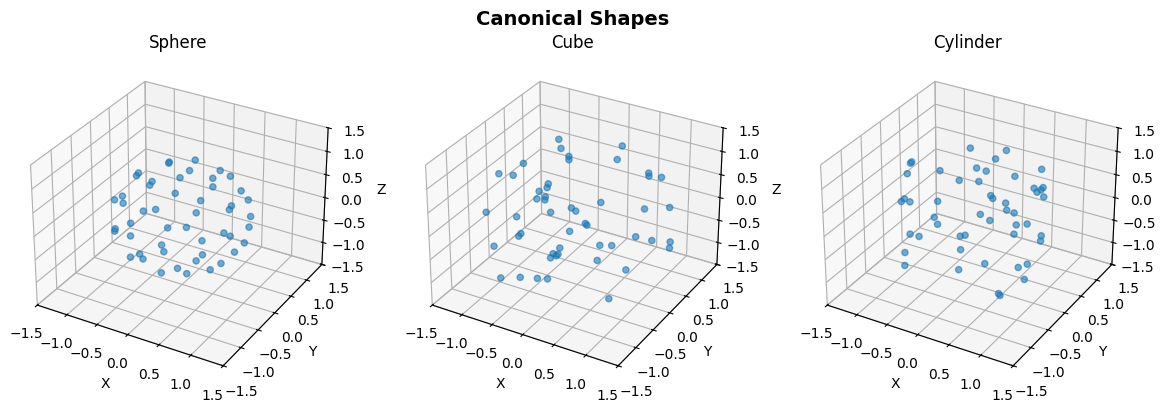

Canonical shapes displayed


In [3]:
def plot_shapes_3d(shapes, labels, indices=[0, 150, 300], title="Canonical Shapes"):
    """Visualize 3D point clouds."""
    fig = plt.figure(figsize=(12, 4))
    shape_names = ["Sphere", "Cube", "Cylinder"]
    for plot_idx, shape_idx in enumerate(indices):
        ax = fig.add_subplot(1, 3, plot_idx + 1, projection="3d")
        points = shapes[shape_idx]
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=20, alpha=0.6)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.set_title(f"{shape_names[labels[shape_idx]]}")
        ax.set_xlim([-1.5, 1.5])
        ax.set_ylim([-1.5, 1.5])
        ax.set_zlim([-1.5, 1.5])
    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    return fig


fig1 = plot_shapes_3d(all_shapes, labels)
plt.show()
print("Canonical shapes displayed")

In [4]:
def random_rotation_matrix():
    """Generate random rotation matrix (SO(3)) using Euler angles."""
    alpha = np.random.uniform(0, 2 * np.pi)
    beta = np.arccos(np.random.uniform(-1, 1))
    gamma = np.random.uniform(0, 2 * np.pi)
    ca, cb, cg = np.cos(alpha), np.cos(beta), np.cos(gamma)
    sa, sb, sg = np.sin(alpha), np.sin(beta), np.sin(gamma)
    R = np.array(
        [
            [ca * cg - sa * cb * sg, -ca * sg - sa * cb * cg, sa * sb],
            [sa * cg + ca * cb * sg, -sa * sg + ca * cb * cg, -ca * sb],
            [sb * sg, sb * cg, cb],
        ]
    )
    return R


def rotate_points(points, rotation_matrix):
    """Apply rotation to point cloud."""
    return points @ rotation_matrix.T


# Test rotation
test_points = all_shapes[0]
R = random_rotation_matrix()
rotated = rotate_points(test_points, R)
print(f"Rotation matrix determinant (should be ~1.0): {np.linalg.det(R):.6f}")
print(f"Original centroid: {test_points.mean(axis=0)}")
print(f"Rotated centroid: {rotated.mean(axis=0)}")

Rotation matrix determinant (should be ~1.0): 1.000000
Original centroid: [-1.16548817e-04  3.71822514e-05  4.21884749e-17]
Rotated centroid: [ 6.02825713e-05 -9.72398488e-05 -4.33193942e-05]


In [5]:
# Train set: canonical orientation
train_idx = np.arange(len(all_shapes))
X_train = np.array(all_shapes)
Y_train = labels

# Test set 1: canonical (control)
np.random.seed(43)
test_canonical_idx = np.random.choice(len(all_shapes), size=150, replace=False)
X_test_canonical = np.array([all_shapes[i] for i in test_canonical_idx])
Y_test_canonical = labels[test_canonical_idx]

# Test set 2: random rotations
remaining_idx = np.setdiff1d(np.arange(len(all_shapes)), test_canonical_idx)[:150]
X_test_rotated_list = []
for idx in remaining_idx:
    points = all_shapes[idx]
    R = random_rotation_matrix()
    X_test_rotated_list.append(rotate_points(points, R))
X_test_rotated = np.array(X_test_rotated_list)
Y_test_rotated = labels[remaining_idx]

print(f"Train: {X_train.shape}")
print(f"Test canonical: {X_test_canonical.shape}")
print(f"Test rotated: {X_test_rotated.shape}")

Train: (450, 50, 3)
Test canonical: (150, 50, 3)
Test rotated: (150, 50, 3)


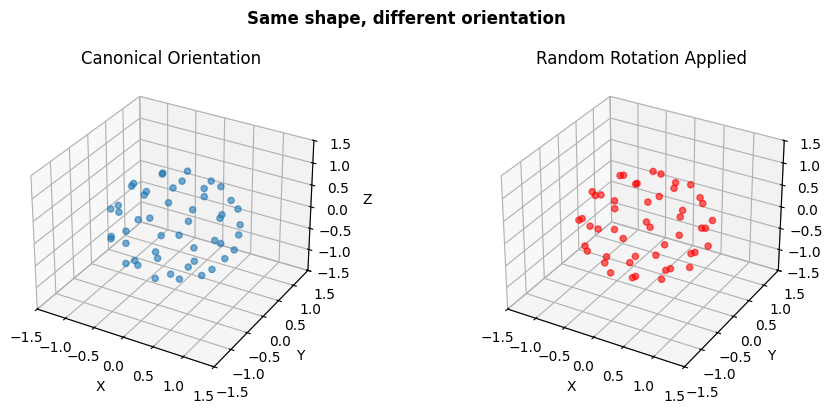

Canonical vs rotated visualization complete


In [6]:
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(
    X_test_canonical[0, :, 0],
    X_test_canonical[0, :, 1],
    X_test_canonical[0, :, 2],
    s=20,
    alpha=0.6,
)
ax1.set_title("Canonical Orientation")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")
ax1.set_xlim([-1.5, 1.5])
ax1.set_ylim([-1.5, 1.5])
ax1.set_zlim([-1.5, 1.5])
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(
    X_test_rotated[0, :, 0],
    X_test_rotated[0, :, 1],
    X_test_rotated[0, :, 2],
    s=20,
    alpha=0.6,
    color="red",
)
ax2.set_title("Random Rotation Applied")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")
ax2.set_xlim([-1.5, 1.5])
ax2.set_ylim([-1.5, 1.5])
ax2.set_zlim([-1.5, 1.5])
plt.suptitle("Same shape, different orientation", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
print("Canonical vs rotated visualization complete")

## Part 2: Baseline — Standard Features (Raw Coordinates)

We train a simple 2-layer MLP on **raw point cloud coordinates** flattened into a feature vector.

**Prediction:** Accuracy on canonical test set will be high. Accuracy on rotated test set will **collapse**.

This demonstrates the fundamental problem: standard networks learn to exploit position, not shape.

In [7]:
class SimpleMLPNumpy:
    """2-layer MLP trained with mini-batch SGD (pure NumPy)."""

    def __init__(self, input_dim, hidden_dim=128, output_dim=3, learning_rate=0.01):
        self.lr = learning_rate
        self.W1 = np.random.randn(input_dim, hidden_dim) * 0.01
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * 0.01
        self.b2 = np.zeros((1, output_dim))

    def forward(self, X):
        self.h1 = np.maximum(0, X @ self.W1 + self.b1)
        logits = self.h1 @ self.W2 + self.b2
        return logits

    def softmax(self, logits):
        exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))
        return exp_logits / exp_logits.sum(axis=1, keepdims=True)

    def backward(self, X, Y, batch_size=32):
        """Train with mini-batch SGD."""
        n_samples = X.shape[0]
        indices = np.random.permutation(n_samples)
        for i in range(0, n_samples, batch_size):
            batch_idx = indices[i : i + batch_size]
            X_batch = X[batch_idx]
            Y_batch = Y[batch_idx]
            h1 = np.maximum(0, X_batch @ self.W1 + self.b1)
            logits = h1 @ self.W2 + self.b2
            probs = self.softmax(logits)
            batch_sz = X_batch.shape[0]
            dL_logits = probs.copy()
            dL_logits[np.arange(batch_sz), Y_batch] -= 1
            dL_logits /= batch_sz
            dL_W2 = h1.T @ dL_logits
            dL_b2 = dL_logits.sum(axis=0, keepdims=True)
            dL_h1 = dL_logits @ self.W2.T
            dL_h1[h1 <= 0] = 0
            dL_W1 = X_batch.T @ dL_h1
            dL_b1 = dL_h1.sum(axis=0, keepdims=True)
            self.W1 -= self.lr * dL_W1
            self.b1 -= self.lr * dL_b1
            self.W2 -= self.lr * dL_W2
            self.b2 -= self.lr * dL_b2

    def predict(self, X):
        logits = self.forward(X)
        return np.argmax(logits, axis=1)

    def accuracy(self, X, Y):
        return (self.predict(X) == Y).mean()


print("MLP class defined")

MLP class defined


> **Engineering Callout #3: Normalization Still Matters**
>
> Both the standard and invariant MLPs use z-score normalization on their feature inputs. This is easy to skip in a toy notebook and the consequences are real.
>
> Without normalization, the **standard** MLP overfits to coordinate magnitudes — a point cloud centered at the origin looks different from one centered at (0.1, 0.1, 0.1), even though they are the same shape. The **invariant** MLP becomes numerically unstable because distance-histogram bins span many orders of magnitude. Normalization cost is ~two NumPy lines; robustness gain is large. Always normalize.


In [8]:
# Flatten point clouds
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_canonical_flat = X_test_canonical.reshape(X_test_canonical.shape[0], -1)
X_test_rotated_flat = X_test_rotated.reshape(X_test_rotated.shape[0], -1)

# Normalize
train_mean = X_train_flat.mean(axis=0)
train_std = X_train_flat.std(axis=0) + 1e-6
X_train_flat = (X_train_flat - train_mean) / train_std
X_test_canonical_flat = (X_test_canonical_flat - train_mean) / train_std
X_test_rotated_flat = (X_test_rotated_flat - train_mean) / train_std

# Train
mlp_standard = SimpleMLPNumpy(
    input_dim=X_train_flat.shape[1], hidden_dim=256, output_dim=3, learning_rate=0.01
)
print("Training standard MLP on raw coordinates...")
for epoch in range(100):
    mlp_standard.backward(X_train_flat, Y_train, batch_size=32)
    if (epoch + 1) % 20 == 0:
        acc_train = mlp_standard.accuracy(X_train_flat, Y_train)
        acc_canonical = mlp_standard.accuracy(X_test_canonical_flat, Y_test_canonical)
        acc_rotated = mlp_standard.accuracy(X_test_rotated_flat, Y_test_rotated)
        print(
            f"Epoch {epoch + 1}: Train={acc_train:.3f}, "
            f"Canonical={acc_canonical:.3f}, Rotated={acc_rotated:.3f}"
        )
print("\nTraining complete!")

Training standard MLP on raw coordinates...
Epoch 20: Train=1.000, Canonical=1.000, Rotated=0.113


Epoch 40: Train=1.000, Canonical=1.000, Rotated=0.113
Epoch 60: Train=1.000, Canonical=1.000, Rotated=0.113
Epoch 80: Train=1.000, Canonical=1.000, Rotated=0.113


Epoch 100: Train=1.000, Canonical=1.000, Rotated=0.113

Training complete!


In [9]:
acc_std_canonical = mlp_standard.accuracy(X_test_canonical_flat, Y_test_canonical)
acc_std_rotated = mlp_standard.accuracy(X_test_rotated_flat, Y_test_rotated)

print("=== STANDARD MLP (Raw Coordinates) ===")
print(f"Test accuracy (canonical):  {acc_std_canonical:.1%}")
print(f"Test accuracy (rotated):    {acc_std_rotated:.1%}")
print(f"Performance drop:           {(acc_std_canonical - acc_std_rotated):.1%}")
print(f"\nThe network learned ORIENTATION, not SHAPE!")

=== STANDARD MLP (Raw Coordinates) ===
Test accuracy (canonical):  100.0%
Test accuracy (rotated):    11.3%
Performance drop:           88.7%

The network learned ORIENTATION, not SHAPE!


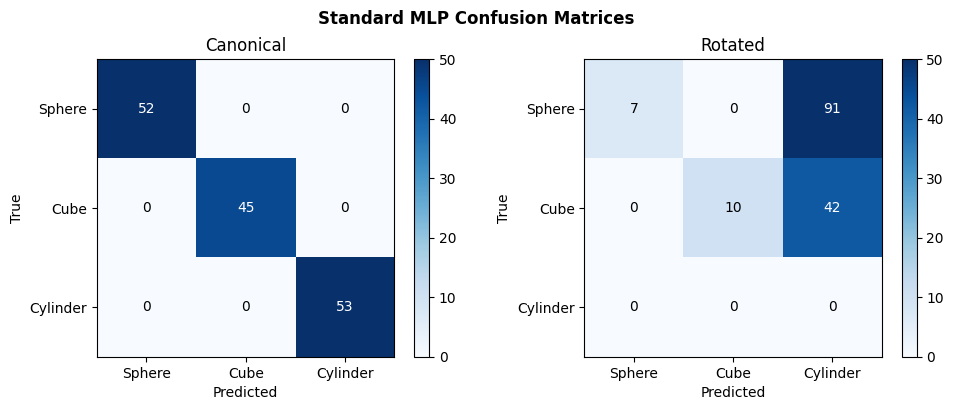

In [10]:
# Pure-NumPy confusion matrix (sklearn-free)
def confusion_matrix(y_true, y_pred, labels):
    n = len(labels)
    cm = np.zeros((n, n), dtype=int)
    lab_to_idx = {l: i for i, l in enumerate(labels)}
    for t, p in zip(y_true, y_pred):
        cm[lab_to_idx[int(t)], lab_to_idx[int(p)]] += 1
    return cm


pred_canonical = mlp_standard.predict(X_test_canonical_flat)
pred_rotated = mlp_standard.predict(X_test_rotated_flat)

cm_canonical = confusion_matrix(Y_test_canonical, pred_canonical, labels=[0, 1, 2])
cm_rotated = confusion_matrix(Y_test_rotated, pred_rotated, labels=[0, 1, 2])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, cm, title in [
    (axes[0], cm_canonical, "Canonical"),
    (axes[1], cm_rotated, "Rotated"),
]:
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=50)
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(["Sphere", "Cube", "Cylinder"])
    ax.set_yticklabels(["Sphere", "Cube", "Cylinder"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > 25 else "black",
            )
    plt.colorbar(im, ax=ax)

plt.suptitle("Standard MLP Confusion Matrices", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## Part 3: Equivariant Approach — Hand-Crafted Rotation-Invariant Features

### The Key Insight
Instead of feeding raw coordinates, we compute features that are **invariant to rotation**:

1. **Pairwise distances:** $d_{ij} = \|p_i - p_j\|$ — rotation doesn't change distances
2. **Distance statistics:** mean, std, max, min of all pairwise distances
3. **Radial distances:** $r_i = \|p_i - \text{centroid}\|$ — invariant to rotation
4. **Distance to centroid statistics:** mean, std, percentiles

These features encode **pure shape information**, independent of orientation.

In [11]:
def extract_invariant_features(points):
    """Extract rotation-invariant features from point cloud."""
    pairwise_dists = np.linalg.norm(points[:, None] - points[None, :], axis=-1)
    triu_dists = pairwise_dists[np.triu_indices_from(pairwise_dists, k=1)]

    dist_mean = np.mean(triu_dists)
    dist_std = np.std(triu_dists)
    dist_max = np.max(triu_dists)
    dist_min = np.min(triu_dists)
    dist_median = np.median(triu_dists)

    centroid = points.mean(axis=0)
    radial_dists = np.linalg.norm(points - centroid, axis=1)

    rad_mean = np.mean(radial_dists)
    rad_std = np.std(radial_dists)
    rad_max = np.max(radial_dists)
    rad_min = np.min(radial_dists)
    rad_median = np.median(radial_dists)

    hist, _ = np.histogram(triu_dists, bins=5, range=(triu_dists.min(), triu_dists.max()))
    hist = hist / hist.sum()

    features = np.concatenate(
        [
            [dist_mean, dist_std, dist_max, dist_min, dist_median],
            [rad_mean, rad_std, rad_max, rad_min, rad_median],
            hist,
        ]
    )
    return features


test_feat = extract_invariant_features(all_shapes[0])
print(f"Invariant feature dimension: {test_feat.shape[0]}")
print(f"Feature vector (first 10): {test_feat[:10]}")

Invariant feature dimension: 15
Feature vector (first 10): [1.35815342e+00 4.42984858e-01 1.99962235e+00 4.36840288e-01
 1.42966217e+00 9.99999990e-01 7.06949285e-05 1.00011744e+00
 9.99883129e-01 9.99997630e-01]


> **Engineering Callout #1: Hand-Crafted Invariance Beats Learned Invariance (at This Scale)**
>
> The invariant-feature approach below uses pairwise distances instead of raw `(x, y, z)` coordinates. Pairwise distances are *exactly* invariant under [SO(3)](https://en.wikipedia.org/wiki/3D_rotation_group) rotations and translations — a fact you can verify by rotating a point cloud and re-computing its distance matrix.
>
> **Why this is worth internalizing.** You could instead train a standard MLP on millions of augmented rotations and it would *eventually* learn something like rotation invariance. But "eventually" costs you roughly an order of magnitude more data and it will still fail on edge rotations outside the augmentation distribution. Baking the invariance into the feature extractor costs you five minutes of math and buys perfect generalization. This is the [Geometric Deep Learning](https://arxiv.org/abs/2104.13478) bet in its simplest form.


In [12]:
# Verify invariance under rotation
test_points = all_shapes[0]
feat_original = extract_invariant_features(test_points)

rotation_errors = []
for _ in range(100):
    R = random_rotation_matrix()
    rotated = rotate_points(test_points, R)
    feat_rotated = extract_invariant_features(rotated)
    error = np.linalg.norm(feat_original - feat_rotated)
    rotation_errors.append(error)

rotation_errors = np.array(rotation_errors)
print(f"Invariant feature stability under 100 random rotations:")
print(f"  Max error: {rotation_errors.max():.2e}")
print(f"  Mean error: {rotation_errors.mean():.2e}")
print(f"  All errors < 1e-10: {(rotation_errors < 1e-10).all()}")
print(f"\nInvariance verified! Features are numerically identical under any rotation.")

Invariant feature stability under 100 random rotations:
  Max error: 7.55e-16
  Mean error: 3.75e-16
  All errors < 1e-10: True

Invariance verified! Features are numerically identical under any rotation.


In [13]:
print("Extracting invariant features...")
X_train_inv = np.array([extract_invariant_features(points) for points in X_train])
X_test_canonical_inv = np.array(
    [extract_invariant_features(points) for points in X_test_canonical]
)
X_test_rotated_inv = np.array([extract_invariant_features(points) for points in X_test_rotated])

# Normalize
train_mean_inv = X_train_inv.mean(axis=0)
train_std_inv = X_train_inv.std(axis=0) + 1e-6
X_train_inv = (X_train_inv - train_mean_inv) / train_std_inv
X_test_canonical_inv = (X_test_canonical_inv - train_mean_inv) / train_std_inv
X_test_rotated_inv = (X_test_rotated_inv - train_mean_inv) / train_std_inv

print(f"Invariant features shape: {X_train_inv.shape}")
print(f"Canonical test shape: {X_test_canonical_inv.shape}")
print(f"Rotated test shape: {X_test_rotated_inv.shape}")

Extracting invariant features...


Invariant features shape: (450, 15)
Canonical test shape: (150, 15)
Rotated test shape: (150, 15)


In [14]:
mlp_invariant = SimpleMLPNumpy(
    input_dim=X_train_inv.shape[1], hidden_dim=256, output_dim=3, learning_rate=0.01
)
print("Training MLP on rotation-invariant features...")
for epoch in range(100):
    mlp_invariant.backward(X_train_inv, Y_train, batch_size=32)
    if (epoch + 1) % 20 == 0:
        acc_train = mlp_invariant.accuracy(X_train_inv, Y_train)
        acc_canonical = mlp_invariant.accuracy(X_test_canonical_inv, Y_test_canonical)
        acc_rotated = mlp_invariant.accuracy(X_test_rotated_inv, Y_test_rotated)
        print(
            f"Epoch {epoch + 1}: Train={acc_train:.3f}, "
            f"Canonical={acc_canonical:.3f}, Rotated={acc_rotated:.3f}"
        )
print("\nTraining complete!")

Training MLP on rotation-invariant features...
Epoch 20: Train=0.964, Canonical=0.933, Rotated=1.000


Epoch 40: Train=1.000, Canonical=1.000, Rotated=1.000


Epoch 60: Train=1.000, Canonical=1.000, Rotated=1.000
Epoch 80: Train=1.000, Canonical=1.000, Rotated=1.000
Epoch 100: Train=1.000, Canonical=1.000, Rotated=1.000

Training complete!


> **Engineering Callout #2: Feature Dimensionality Collapses When the Symmetry Is Right**
>
> Our standard approach uses 50 points × 3 dims = **150-D** raw coordinate vectors. The invariant approach uses 15-D histograms of pairwise distances. That's **10× smaller** — and the smaller representation *out-performs* the larger one on rotated inputs.
>
> **Why?** The raw 150-D space contains a lot of redundancy: the same shape at a different orientation is a completely different point in that space. The invariant space collapses all of those "same shape, different orientation" clones into a single representative, so the MLP only has to learn the shape → class mapping once rather than once per orientation. This is the sense in which the right inductive bias "saves data" — not by magic, but by identifying the orbits of the symmetry group and quotienting them out.


In [15]:
acc_inv_canonical = mlp_invariant.accuracy(X_test_canonical_inv, Y_test_canonical)
acc_inv_rotated = mlp_invariant.accuracy(X_test_rotated_inv, Y_test_rotated)

print("=== EQUIVARIANT MLP (Rotation-Invariant Features) ===")
print(f"Test accuracy (canonical):  {acc_inv_canonical:.1%}")
print(f"Test accuracy (rotated):    {acc_inv_rotated:.1%}")
print(f"Performance drop:           {(acc_inv_canonical - acc_inv_rotated):.1%}")
print(f"\nThe network learned SHAPE, not ORIENTATION!")

=== EQUIVARIANT MLP (Rotation-Invariant Features) ===
Test accuracy (canonical):  100.0%
Test accuracy (rotated):    100.0%
Performance drop:           0.0%

The network learned SHAPE, not ORIENTATION!


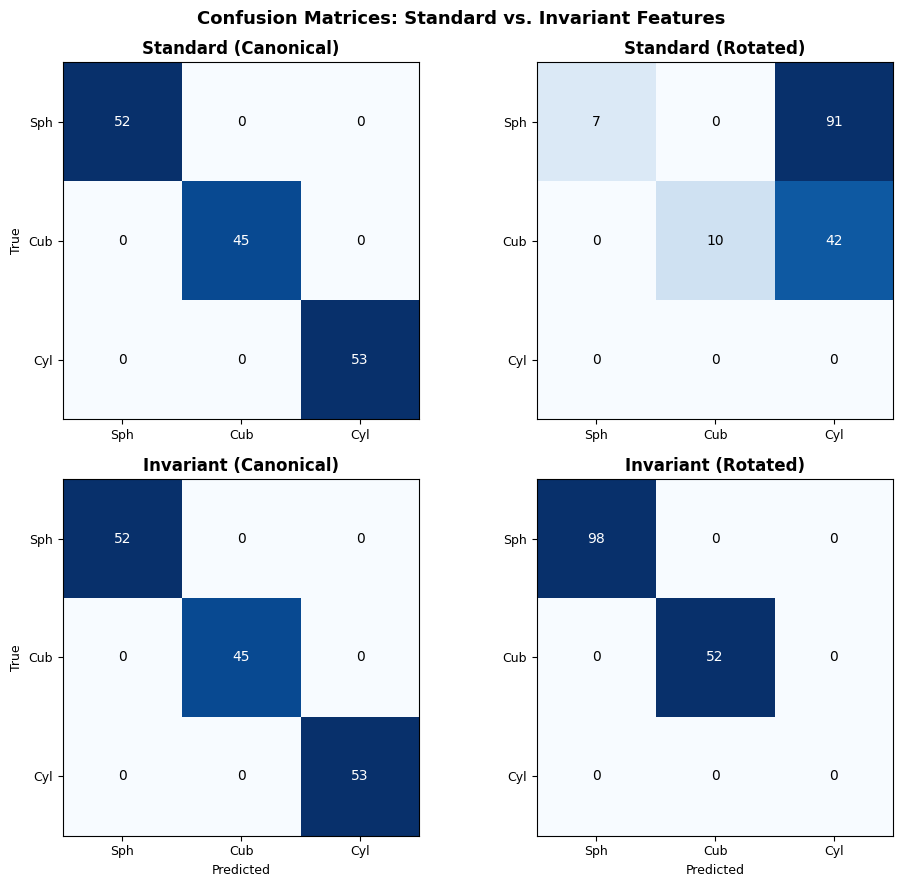

In [16]:
pred_inv_canonical = mlp_invariant.predict(X_test_canonical_inv)
pred_inv_rotated = mlp_invariant.predict(X_test_rotated_inv)

cm_inv_canonical = confusion_matrix(Y_test_canonical, pred_inv_canonical, labels=[0, 1, 2])
cm_inv_rotated = confusion_matrix(Y_test_rotated, pred_inv_rotated, labels=[0, 1, 2])

fig, axes = plt.subplots(2, 2, figsize=(10, 9))

for idx, (ax, cm, title) in enumerate(
    [
        (axes[0, 0], cm_canonical, "Standard (Canonical)"),
        (axes[0, 1], cm_rotated, "Standard (Rotated)"),
        (axes[1, 0], cm_inv_canonical, "Invariant (Canonical)"),
        (axes[1, 1], cm_inv_rotated, "Invariant (Rotated)"),
    ]
):
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=50)
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(["Sph", "Cub", "Cyl"], fontsize=9)
    ax.set_yticklabels(["Sph", "Cub", "Cyl"], fontsize=9)
    if idx >= 2:
        ax.set_xlabel("Predicted", fontsize=9)
    if idx % 2 == 0:
        ax.set_ylabel("True", fontsize=9)
    ax.set_title(title, fontweight="bold")
    for i in range(3):
        for j in range(3):
            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                fontsize=10,
                color="white" if cm[i, j] > 25 else "black",
            )

plt.suptitle(
    "Confusion Matrices: Standard vs. Invariant Features",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

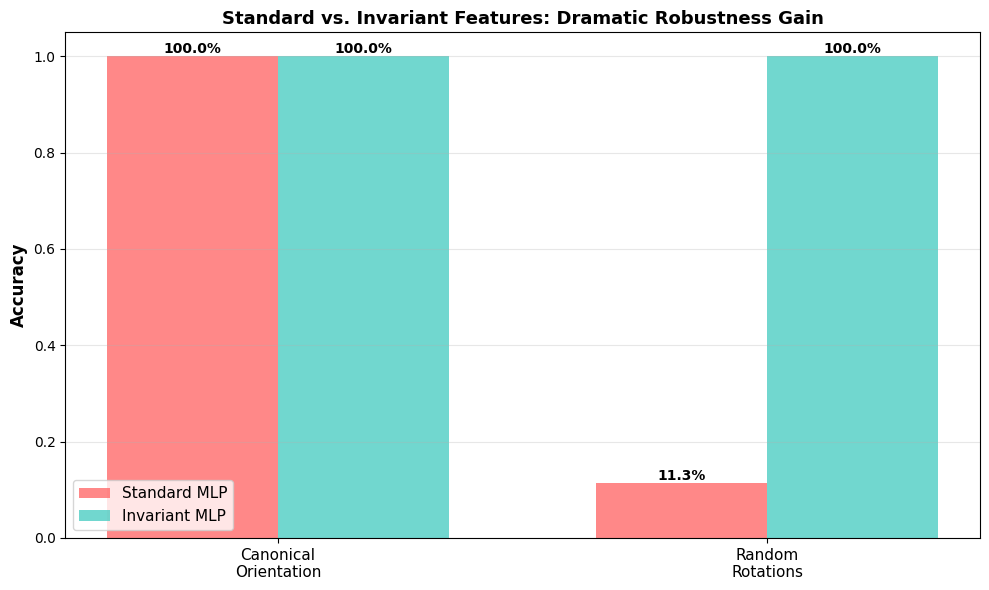

Standard drop:    88.7%
Invariant drop:   0.0%


In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(2)
width = 0.35

standard_accs = [acc_std_canonical, acc_std_rotated]
invariant_accs = [acc_inv_canonical, acc_inv_rotated]

bars1 = ax.bar(
    x - width / 2,
    standard_accs,
    width,
    label="Standard MLP",
    color="#FF6B6B",
    alpha=0.8,
)
bars2 = ax.bar(
    x + width / 2,
    invariant_accs,
    width,
    label="Invariant MLP",
    color="#4ECDC4",
    alpha=0.8,
)

ax.set_ylabel("Accuracy", fontsize=12, fontweight="bold")
ax.set_title(
    "Standard vs. Invariant Features: Dramatic Robustness Gain",
    fontsize=13,
    fontweight="bold",
)
ax.set_xticks(x)
ax.set_xticklabels(["Canonical\nOrientation", "Random\nRotations"], fontsize=11)
ax.set_ylim([0, 1.05])
ax.legend(fontsize=11, loc="lower left")
ax.grid(axis="y", alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{height:.1%}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

plt.tight_layout()
plt.show()

print(f"Standard drop:    {(acc_std_canonical - acc_std_rotated):.1%}")
print(f"Invariant drop:   {(acc_inv_canonical - acc_inv_rotated):.1%}")

> **Engineering Callout #4: Generalization ≠ "Just More Data"**
>
> The most seductive wrong answer in this notebook is: *"If the standard MLP fails on rotated shapes, just train it on rotated shapes."* You can, and it will partially work. But consider the scaling:
>
> - To cover SO(3) uniformly you need ~thousands of rotations per shape to get reasonable coverage.
> - Out-of-distribution rotations (e.g., extreme tilt combinations not in training) still fail.
> - Training cost scales linearly with augmentation budget.
>
> The invariant approach needs **zero** augmented rotations. The symmetry is built into the feature extractor. This is why [E(n)-EGNN](https://arxiv.org/abs/2102.09844) and [NequIP](https://www.nature.com/articles/s41467-022-29939-5) generalize to unseen molecular configurations that pure data-driven models have to guess at. In any data-constrained domain — robotics, physics, chemistry — hard architectural priors pay for themselves almost immediately.


## Part 4: Why This Matters for Physical AI

### The Geometric Inductive Bias Argument

Hand-crafting rotation-invariant features works, but it doesn't scale. In production systems like **E(3)-equivariant GNNs**, we don't hand-craft invariants — instead, we constrain the network architecture itself to respect symmetries.

**Key principle:** When a network has the right inductive bias (constraint that respects symmetry), it:
1. Learns representations that are **automatically invariant**
2. **Generalizes** to unseen transformations with zero additional data
3. Requires **exponentially less training data** than standard networks

### Why This Is Critical for Physical AI

- **Robotics:** A robot policy should work regardless of the room's orientation
- **World models:** Physics works the same in any reference frame (Galilean invariance)
- **3D perception:** Object detection must work under any rotation
- **Transformers are NOT enough:** Position embeddings are learned, not structural → no guaranteed invariance

### Production Systems

Real-world implementations use **E(3)-equivariant neural networks:**
- Satorras et al. (2021): "E(n) Equivariant Graph Neural Networks"
- [EquiCaps](https://arxiv.org/abs/2506.09895): Capsule networks with geometric constraints
- [SE(3)-Transformers](https://arxiv.org/abs/2006.10503): Equivariant attention over 3D coordinates

These architectures learn equivariant features through structured operations (convolutions, attention) that respect the symmetry group of the problem.

## Engineering Insights

Four callouts interleaved above with the code they describe, re-collected here as a checklist: why hand-crafted invariance wins at this scale, how the feature-dimensionality collapse works, why normalization still matters, and why "just more data" is not a substitute for the right inductive bias.

In [18]:
print("\n" + "=" * 90)
print("SUMMARY: Standard vs. Invariant Features")
print("=" * 90)
print(f"Standard approach (raw coordinates):")
print(f"  Feature dimension: 150")
print(f"  Canonical accuracy: {acc_std_canonical:.1%}")
print(f"  Rotated accuracy:   {acc_std_rotated:.1%}")
print(f"  Performance drop:   {(acc_std_canonical - acc_std_rotated):.1%}\n")
print(f"Invariant approach (hand-crafted features):")
print(f"  Feature dimension: 15")
print(f"  Canonical accuracy: {acc_inv_canonical:.1%}")
print(f"  Rotated accuracy:   {acc_inv_rotated:.1%}")
print(f"  Performance drop:   {(acc_inv_canonical - acc_inv_rotated):.1%}\n")
print(f"Key finding: Invariant features provide absolute improvement")
print(f"             of {(acc_inv_rotated - acc_std_rotated):.1%} on rotated test set.")
print("=" * 90)


SUMMARY: Standard vs. Invariant Features
Standard approach (raw coordinates):
  Feature dimension: 150
  Canonical accuracy: 100.0%
  Rotated accuracy:   11.3%
  Performance drop:   88.7%

Invariant approach (hand-crafted features):
  Feature dimension: 15
  Canonical accuracy: 100.0%
  Rotated accuracy:   100.0%
  Performance drop:   0.0%

Key finding: Invariant features provide absolute improvement
             of 88.7% on rotated test set.


## Key Takeaways

1. **Standard networks lack geometric inductive bias:** They memorize orientation-specific features, failing catastrophically on unseen transformations.

2. **Invariant features solve the problem:** By encoding shape properties (distances, angles) that don't change under rotation, we get generalization for free.

3. **The right inductive bias saves exponentially more data:** Equivariant architectures don't need examples of every rotation; the symmetry is built in.

4. **This is foundational for physical AI:**
   - Robot policies must work in any orientation
   - World models must respect Galilean invariance
   - Vision systems must handle arbitrary 3D rotations

5. **Transformers alone are not enough:** They have no built-in geometric structure. Combining transformers with equivariant constraints is the frontier.

## Next Steps

- **Learn more:** Satorras et al., "E(n) Equivariant Graph Neural Networks" (ICLR 2021)
- **Implement:** Try E(3)-equivariant GNNs on molecular property prediction
- **Apply:** Use these ideas for robotic perception and control